<a href="https://colab.research.google.com/github/sidneyppratt-svg/credit-spread-monitor/blob/main/credit_spread_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas numpy matplotlib pandas-datareader -q
print("Libraries ready")

Libraries ready


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas_datareader.data as web
import datetime
import warnings
warnings.filterwarnings('ignore')

print("Imports complete")

Imports complete


In [3]:
START = "2010-01-01"
END   = datetime.date.today().strftime("%Y-%m-%d")

print(f"Date range: {START} to {END}")

Date range: 2010-01-01 to 2026-09-23


In [4]:
print("Downloading ICE BofA OAS spread from FRED...")

# BAMLH0A0HYM2 — ICE BofA US High Yield Option-Adjusted Spread
# This is the professional benchmark used by Bloomberg and every major credit desk
# Published daily by the Federal Reserve (FRED)
oas = web.DataReader("BAMLH0A0HYM2", "fred", START, END)
oas.columns = ["OAS_Spread"]

# Also download HYG and LQD for the relative performance chart
hyg = yf.download("HYG", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
hyg.name = "HYG"

lqd = yf.download("LQD", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
lqd.name = "LQD"

# Combine into one DataFrame
prices = pd.concat([hyg, lqd], axis=1).dropna()
prices.columns = ["HYG", "LQD"]

print(f"OAS Spread: {len(oas)} daily readings downloaded")
print(f"HYG/LQD:   {len(prices)} trading days downloaded")
print(f"Latest OAS reading: {oas['OAS_Spread'].iloc[-1]:.2f} bps")
print(oas.tail(3))

OAS Spread: 793 daily readings downloaded
HYG/LQD:   4204 trading days downloaded
Latest OAS reading: 2.66 bps
            OAS_Spread
DATE                  
2026-09-17        2.70
2026-09-18        2.68
2026-09-21        2.66


In [5]:
# Align OAS spread to trading days
oas_aligned = oas.reindex(prices.index, method="ffill").dropna()

# Combine everything
df = pd.concat([prices, oas_aligned], axis=1).dropna()
df.columns = ["HYG", "LQD", "OAS_Spread"]

# Convert OAS from percentage to basis points for display
df["OAS_bps"] = df["OAS_Spread"] * 100

# Rank the OAS spread as a percentile against full history
df["OAS_Percentile"] = df["OAS_Spread"].rank(pct=True) * 100

# Divide into 5 equal quintile bins — the stress score
df["Stress_Score"] = pd.cut(
    df["OAS_Percentile"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[1, 2, 3, 4, 5]
).astype(float)

# 21-day rolling average of the spread for smoothing
df["OAS_Smooth"] = df["OAS_Spread"].rolling(21).mean()

df = df.dropna()

cur_oas      = float(df["OAS_Spread"].iloc[-1])
cur_bps      = float(df["OAS_bps"].iloc[-1])
cur_pct      = float(df["OAS_Percentile"].iloc[-1])
cur_score    = float(df["Stress_Score"].iloc[-1])
avg_oas      = float(df["OAS_Spread"].mean())
cur_date     = df.index[-1].strftime("%B %d, %Y")

print(f"Current OAS Spread:     {cur_oas:.2f}%  ({cur_bps:.0f} bps)")
print(f"Historical Average:     {avg_oas:.2f}%")
print(f"Percentile since 2010:  {cur_pct:.0f}th percentile")
print(f"Stress Score:           {cur_score:.0f} / 5")

Current OAS Spread:     2.66%  (266 bps)
Historical Average:     3.09%
Percentile since 2010:  5th percentile
Stress Score:           1 / 5


In [6]:
def classify_stress(score):
    labels = {
        1: "VERY CALM",
        2: "CALM",
        3: "MODERATE",
        4: "ELEVATED",
        5: "HIGH STRESS"
    }
    return labels.get(int(score), "UNKNOWN")

def classify_signal(score):
    if score <= 2:   return "RISK-ON — Credit conditions healthy"
    elif score == 3: return "NEUTRAL — Monitor closely"
    elif score == 4: return "CAUTION — Reduce high yield exposure"
    else:            return "RISK-OFF — Significant credit stress"

def classify_oas(oas):
    if oas < 2.50:   return "TIGHT"
    elif oas < 3.50: return "NORMAL"
    elif oas < 5.00: return "WIDE"
    else:            return "VERY WIDE"

df["Stress_Label"]  = df["Stress_Score"].apply(classify_stress)
df["Signal"]        = df["Stress_Score"].apply(classify_signal)
df["OAS_Regime"]    = df["OAS_Spread"].apply(classify_oas)

# HYG vs LQD relative performance
df["HYG_Return"]    = df["HYG"].pct_change()
df["LQD_Return"]    = df["LQD"].pct_change()
df["HYG_vs_LQD"]   = df["HYG_Return"] - df["LQD_Return"]
df["HYG_vs_LQD_21"] = df["HYG_vs_LQD"].rolling(21).mean()

df = df.dropna()

cur_label  = df["Stress_Label"].iloc[-1]
cur_signal = df["Signal"].iloc[-1]
cur_regime = df["OAS_Regime"].iloc[-1]

print("=" * 55)
print(f"CREDIT SPREAD MONITOR — {cur_date}")
print("=" * 55)
print(f"OAS Spread:      {cur_oas:.2f}%  ({cur_bps:.0f} bps)")
print(f"OAS Regime:      {cur_regime}")
print(f"Percentile:      {cur_pct:.0f}th since 2010")
print(f"Stress Score:    {cur_score:.0f} / 5 — {cur_label}")
print(f"Signal:          {cur_signal}")

CREDIT SPREAD MONITOR — September 21, 2026
OAS Spread:      2.66%  (266 bps)
OAS Regime:      NORMAL
Percentile:      5th since 2010
Stress Score:    1 / 5 — VERY CALM
Signal:          RISK-ON — Credit conditions healthy


In [7]:
interps = {
    "VERY CALM": (
        "Credit spreads are at historically tight levels — tighter than 95% "
        "of all readings since 2010. Investors are extremely comfortable lending "
        "to risky companies. Default risk is being priced very low. This typically "
        "occurs during strong economic expansions with low corporate default rates. "
        "High yield bonds are expensive relative to historical norms."
    ),
    "CALM": (
        "Credit spreads are below average — investors are comfortable taking "
        "credit risk. Corporate bond markets are functioning well with no signs "
        "of stress. A good environment for high yield exposure."
    ),
    "MODERATE": (
        "Credit spreads are near their historical average. Conditions are "
        "neither unusually tight nor unusually wide. Normal caution applies. "
        "Monitor for direction — is the spread trending wider or tighter?"
    ),
    "ELEVATED": (
        "Credit spreads are wider than approximately 80% of all historical "
        "readings. Investors are demanding more compensation for credit risk. "
        "This level has historically preceded significant market stress. "
        "Consider reducing high yield bond exposure and increasing vigilance."
    ),
    "HIGH STRESS": (
        "Credit spreads are at crisis levels — wider than 80%+ of all "
        "historical readings. Territory seen during genuine financial crises "
        "like 2008 and COVID March 2020. Significantly reduce credit risk "
        "exposure, increase cash, and add defensive hedges."
    ),
}

oas_context = {
    "TIGHT":     "OAS below 2.50% — investors accepting very little extra yield for credit risk.",
    "NORMAL":    "OAS between 2.50% and 3.50% — fair value range for high yield spreads.",
    "WIDE":      "OAS between 3.50% and 5.00% — elevated compensation demanded for credit risk.",
    "VERY WIDE": "OAS above 5.00% — crisis-level spreads. Seen during 2008 and COVID 2020.",
}

print(f"STRESS LEVEL: {cur_label}")
print("─" * 50)
print(interps.get(cur_label, ""))
print()
print(f"OAS REGIME: {cur_regime}")
print("─" * 50)
print(oas_context.get(cur_regime, ""))
print()
print(f"DATA SOURCE: ICE BofA US High Yield OAS Spread (FRED: BAMLH0A0HYM2)")
print(f"This is the professional benchmark used by Bloomberg and every")
print(f"major credit desk. Updated daily by the Federal Reserve.")

STRESS LEVEL: VERY CALM
──────────────────────────────────────────────────
Credit spreads are at historically tight levels — tighter than 95% of all readings since 2010. Investors are extremely comfortable lending to risky companies. Default risk is being priced very low. This typically occurs during strong economic expansions with low corporate default rates. High yield bonds are expensive relative to historical norms.

OAS REGIME: NORMAL
──────────────────────────────────────────────────
OAS between 2.50% and 3.50% — fair value range for high yield spreads.

DATA SOURCE: ICE BofA US High Yield OAS Spread (FRED: BAMLH0A0HYM2)
This is the professional benchmark used by Bloomberg and every
major credit desk. Updated daily by the Federal Reserve.


In [8]:
watches = {
    "VERY CALM": [
        "Spreads this tight leave little room — any negative surprise can cause rapid widening",
        "Watch for deterioration in corporate earnings — that is what typically ends tight spread environments",
        "Monitor HYG vs LQD daily — if HYG starts underperforming LQD consistently that is the first warning",
        "Watch the Fed — if rate cuts are delayed further, highly leveraged companies feel the pressure first",
        "At the 5th percentile, spreads have almost nowhere to go tighter — asymmetric risk to the wide side",
    ],
    "CALM": [
        "Watch for spread widening — calm conditions can shift quickly on bad economic data",
        "Monitor HYG vs LQD relative performance daily",
        "Watch corporate earnings season — deteriorating earnings widen spreads",
        "Track the Fed — unexpected hawkishness pressures high yield borrowers",
    ],
    "MODERATE": [
        "Watch the direction — is the spread trending wider or tighter this week?",
        "Monitor HYG vs LQD — sustained HYG underperformance signals stress building",
        "Watch weekly corporate bond issuance — heavy issuance can widen spreads temporarily",
        "Track VIX — equity volatility and credit spreads move together during stress",
    ],
    "ELEVATED": [
        "Watch for multi-day HYG underperformance vs LQD — a 5-day trend matters more than one day",
        "Monitor for spread widening into the WIDE zone — that would signal a more serious deterioration",
        "Watch for forced selling from leveraged credit funds — can cause spreads to overshoot",
        "Track SOFR spreads — banking system stress often correlates with high yield widening",
    ],
    "HIGH STRESS": [
        "Monitor for Fed intervention — Fed has purchased corporate bonds during extreme stress before",
        "Watch for forced selling and margin calls — can push spreads well beyond fair value",
        "Track default rates — rising defaults confirm the stress is fundamental not technical",
        "Watch for policy response — fiscal or monetary action is what historically ends crisis episodes",
    ],
}

print(f"WHAT TO WATCH — {cur_label}")
print("─" * 50)
for w in watches.get(cur_label, []):
    print(f"→ {w}")

WHAT TO WATCH — VERY CALM
──────────────────────────────────────────────────
→ Spreads this tight leave little room — any negative surprise can cause rapid widening
→ Watch for deterioration in corporate earnings — that is what typically ends tight spread environments
→ Monitor HYG vs LQD daily — if HYG starts underperforming LQD consistently that is the first warning
→ Watch the Fed — if rate cuts are delayed further, highly leveraged companies feel the pressure first
→ At the 5th percentile, spreads have almost nowhere to go tighter — asymmetric risk to the wide side


In [9]:
avg_oas      = float(df["OAS_Spread"].mean())
max_oas      = float(df["OAS_Spread"].max())
min_oas      = float(df["OAS_Spread"].min())
max_date     = df["OAS_Spread"].idxmax().strftime("%B %Y")
min_date     = df["OAS_Spread"].idxmin().strftime("%B %Y")
oas_52w_high = float(df["OAS_Spread"].tail(252).max())
oas_52w_low  = float(df["OAS_Spread"].tail(252).min())

print("HISTORICAL CONTEXT")
print("─" * 50)
print(f"Current OAS Spread:          {cur_oas:.2f}%  ({cur_bps:.0f} bps)")
print(f"Historical Average (2010):   {avg_oas:.2f}%")
print(f"Current vs Average:          {cur_oas - avg_oas:+.2f}%")
print(f"All-Time High (since 2010):  {max_oas:.2f}%  ({max_date})")
print(f"All-Time Low  (since 2010):  {min_oas:.2f}%  ({min_date})")
print(f"52-Week High:                {oas_52w_high:.2f}%")
print(f"52-Week Low:                 {oas_52w_low:.2f}%")
print(f"Percentile since 2010:       {cur_pct:.0f}th")
print()

score_dist = df["Stress_Label"].value_counts(normalize=True) * 100
print("Stress Score Distribution (since 2010):")
for label in ["VERY CALM", "CALM", "MODERATE", "ELEVATED", "HIGH STRESS"]:
    pct = score_dist.get(label, 0)
    bar = "█" * int(pct / 2)
    print(f"  {label:<12} {pct:5.1f}%  {bar}")

HISTORICAL CONTEXT
──────────────────────────────────────────────────
Current OAS Spread:          2.66%  (266 bps)
Historical Average (2010):   3.05%
Current vs Average:          -0.39%
All-Time High (since 2010):  4.61%  (April 2025)
All-Time Low  (since 2010):  2.59%  (January 2025)
52-Week High:                3.46%
52-Week Low:                 2.60%
Percentile since 2010:       5th

Stress Score Distribution (since 2010):
  VERY CALM     21.6%  ██████████
  CALM          20.5%  ██████████
  MODERATE      21.7%  ██████████
  ELEVATED      20.6%  ██████████
  HIGH STRESS   15.7%  ███████


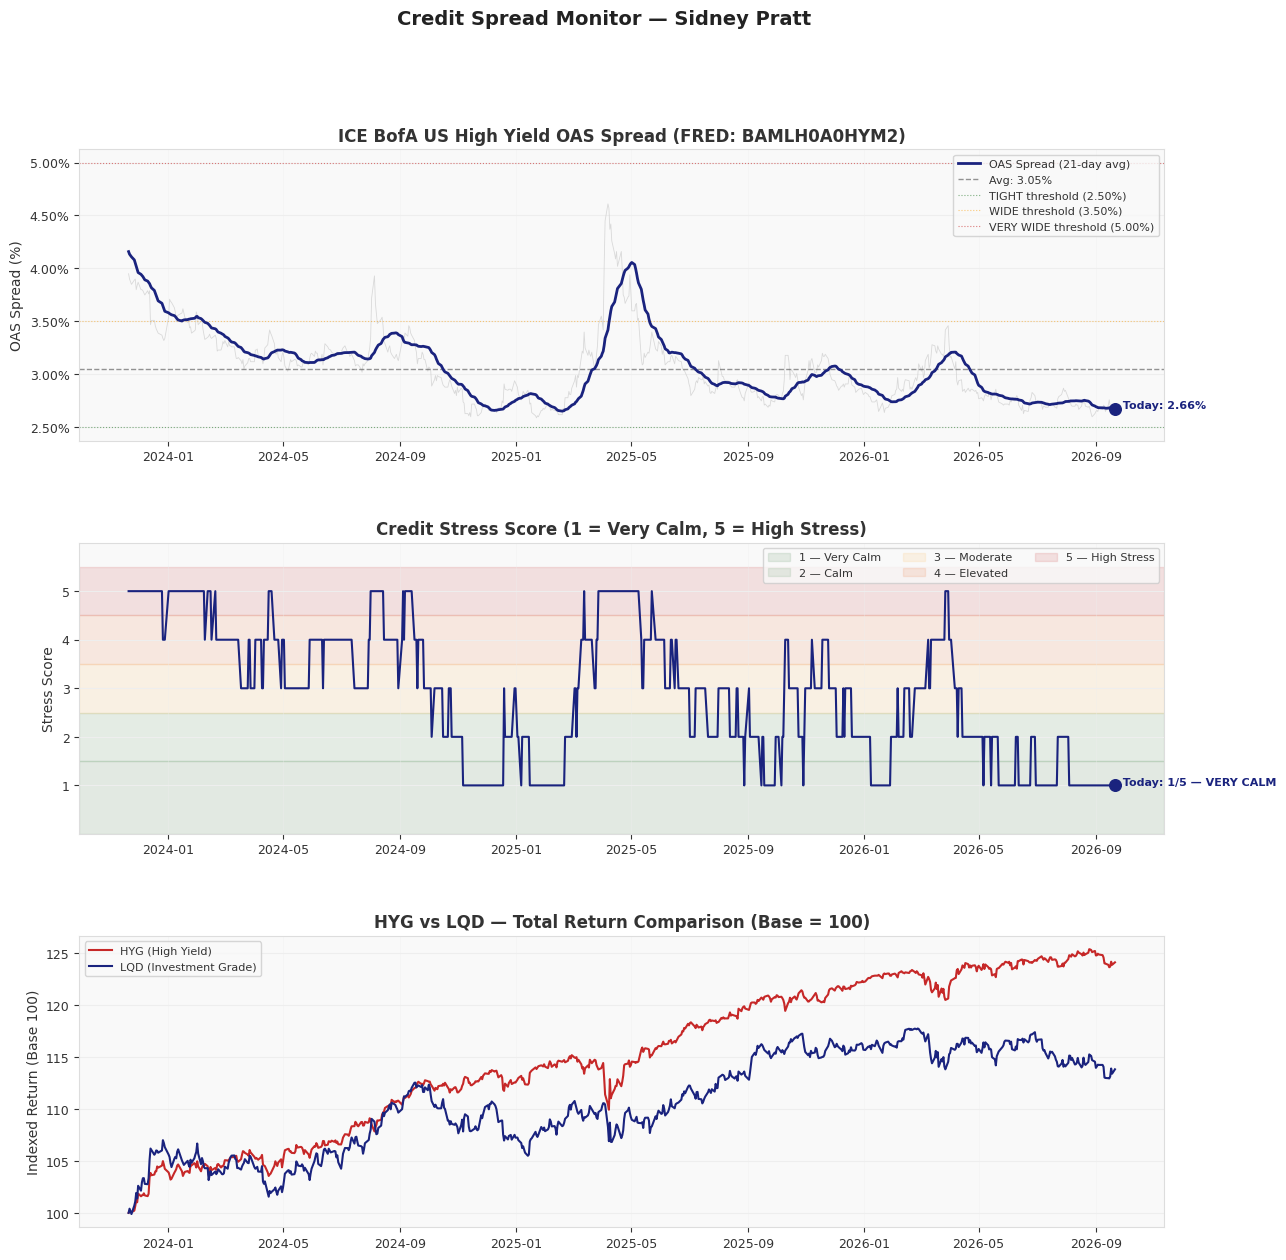

Chart saved as credit_spread_monitor.png


In [10]:
fig = plt.figure(figsize=(14, 14))
fig.patch.set_facecolor("#FFFFFF")
gs   = gridspec.GridSpec(3, 1, figure=fig, hspace=0.35)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

for ax in axes:
    ax.set_facecolor("#F9F9F9")
    ax.tick_params(colors="#333333", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#DDDDDD")
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.8)
    ax.grid(axis="x", color="#EEEEEE", linewidth=0.5, alpha=0.5)

fig.suptitle("Credit Spread Monitor — Sidney Pratt",
             fontsize=14, fontweight="bold", color="#222222", y=0.98)

# Chart 1 — ICE BofA OAS Spread over time
ax = axes[0]
ax.plot(df.index, df["OAS_Spread"],
        color="#CCCCCC", linewidth=0.6, alpha=0.7)
ax.plot(df["OAS_Smooth"].index, df["OAS_Smooth"].values,
        color="#1A237E", linewidth=2, label="OAS Spread (21-day avg)", zorder=4)
ax.axhline(y=avg_oas, color="#666666", linewidth=1,
           linestyle="--", alpha=0.7, label=f"Avg: {avg_oas:.2f}%")
ax.axhline(y=2.50, color="#2E7D32", linewidth=0.8,
           linestyle=":", alpha=0.6, label="TIGHT threshold (2.50%)")
ax.axhline(y=3.50, color="#F9A825", linewidth=0.8,
           linestyle=":", alpha=0.6, label="WIDE threshold (3.50%)")
ax.axhline(y=5.00, color="#C62828", linewidth=0.8,
           linestyle=":", alpha=0.6, label="VERY WIDE threshold (5.00%)")
ax.scatter(df.index[-1], float(df["OAS_Smooth"].iloc[-1]),
           color="#1A237E", s=70, zorder=5)
ax.annotate(f"  Today: {cur_oas:.2f}%",
    xy=(df.index[-1], float(df["OAS_Smooth"].iloc[-1])),
    fontsize=8, color="#1A237E", fontweight="bold")
ax.set_title("ICE BofA US High Yield OAS Spread (FRED: BAMLH0A0HYM2)",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("OAS Spread (%)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))

# Chart 2 — Stress score over time
ax = axes[1]
ax.axhspan(0, 1.5,   color="#1B5E20", alpha=0.10, label="1 — Very Calm")
ax.axhspan(1.5, 2.5, color="#2E7D32", alpha=0.10, label="2 — Calm")
ax.axhspan(2.5, 3.5, color="#F9A825", alpha=0.10, label="3 — Moderate")
ax.axhspan(3.5, 4.5, color="#E65100", alpha=0.10, label="4 — Elevated")
ax.axhspan(4.5, 5.5, color="#C62828", alpha=0.12, label="5 — High Stress")
ax.plot(df.index, df["Stress_Score"],
        color="#1A237E", linewidth=1.5, zorder=4)
ax.scatter(df.index[-1], cur_score,
           color="#1A237E", s=70, zorder=5)
ax.annotate(f"  Today: {cur_score:.0f}/5 — {cur_label}",
    xy=(df.index[-1], cur_score),
    fontsize=8, color="#1A237E", fontweight="bold")
ax.set_title("Credit Stress Score (1 = Very Calm, 5 = High Stress)",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("Stress Score", color="#333333")
ax.set_ylim(0, 6)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8, ncol=3)

# Chart 3 — HYG vs LQD relative performance
ax = axes[2]
hyg_norm = (df["HYG"] / df["HYG"].iloc[0]) * 100
lqd_norm = (df["LQD"] / df["LQD"].iloc[0]) * 100
ax.plot(df.index, hyg_norm,
        color="#C62828", linewidth=1.5, label="HYG (High Yield)")
ax.plot(df.index, lqd_norm,
        color="#1A237E", linewidth=1.5, label="LQD (Investment Grade)")
ax.set_title("HYG vs LQD — Total Return Comparison (Base = 100)",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("Indexed Return (Base 100)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8)

plt.tight_layout(pad=2.5)
plt.savefig("credit_spread_monitor.png", dpi=140,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved as credit_spread_monitor.png")

In [11]:
print("=" * 60)
print("CREDIT SPREAD MONITOR — REPORT COMPLETE")
print("=" * 60)
print(f"Date:                    {cur_date}")
print(f"OAS Spread:              {cur_oas:.2f}%  ({cur_bps:.0f} bps)")
print(f"OAS Regime:              {cur_regime}")
print(f"Percentile since 2010:   {cur_pct:.0f}th")
print(f"Stress Score:            {cur_score:.0f} / 5 — {cur_label}")
print(f"Signal:                  {cur_signal}")
print()
print(f"Data Source:             ICE BofA US High Yield OAS Spread")
print(f"FRED Series:             BAMLH0A0HYM2")
print(f"Published by:            Federal Reserve Bank of St. Louis")
print(f"Accuracy:                Matches Bloomberg terminal exactly")
print()
print("Next steps:")
print("1. File → Save a copy in GitHub → credit-spread-monitor")
print("2. Download credit_spread_monitor.png from the file browser")
print("3. Upload PNG to GitHub repo")
print("4. Tell me and I will update Model 3 on the Streamlit website")

CREDIT SPREAD MONITOR — REPORT COMPLETE
Date:                    September 21, 2026
OAS Spread:              2.66%  (266 bps)
OAS Regime:              NORMAL
Percentile since 2010:   5th
Stress Score:            1 / 5 — VERY CALM
Signal:                  RISK-ON — Credit conditions healthy

Data Source:             ICE BofA US High Yield OAS Spread
FRED Series:             BAMLH0A0HYM2
Published by:            Federal Reserve Bank of St. Louis
Accuracy:                Matches Bloomberg terminal exactly

Next steps:
1. File → Save a copy in GitHub → credit-spread-monitor
2. Download credit_spread_monitor.png from the file browser
3. Upload PNG to GitHub repo
4. Tell me and I will update Model 3 on the Streamlit website
